# LV3 - Pandas

- dataset može sadržavati tri vrste podataka: numeričke, nominalne ili ordinalne
- na ispitu je bitno ovisno o tipu podataka obraditi podatke u datasetu. numeričke značajke moramo skalirati (minmax ili standard), a kategoričke značajke moramo enkodirati (npr. one hot encoding)

### Strukture podataka u Pandasu

- Series - 1D objekt, sličan polju/nizu samo što svaki element ima indeks

In [4]:
import pandas as pd

s = pd.Series([10, 20, 30, 40], index=["a", "b", "c", "d"])

s

a    10
b    20
c    30
d    40
dtype: int64

- DataFrame - 2D objekt, svaki stupac ima svoje ime i sadrži podatke istog tipa. svaki redak ima indeks i čini jedan "unos" u datasetu

In [6]:
df = pd.DataFrame({
    "Ime": ["Ana", "Marko", "Ivana"],
    "Godine": [22, 25, 28],
    "Grad": ["Zagreb", "Split", "Rijeka"]
})

df

,Ime,Godine,Grad
0,Ana,22,Zagreb
1,Marko,25,Split
2,Ivana,28,Rijeka


- iako možemo ovako sami praviti dataframe-ove ručnim unošenjem podataka, ono što ćemo mi najčešće raditi je unos podataka iz neke datoteke, većinom csv
- pandas ima i neke ugrađene datasetove za vježbu, npr. iris

In [9]:
data = pd.read_csv('data_C02_emission.csv')

data.head(5)

,Make,Model,Vehicle Class,Engine Size (L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100km),Fuel Consumption Hwy (L/100km),Fuel Consumption Comb (L/100km),Fuel Consumption Comb (mpg),CO2 Emissions (g/km)
0,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,199
1,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS9,Z,12.3,9.2,10.9,26,254
2,Acura,MDX SH-AWD A-SPEC,SUV: Small,3.5,6,AS9,Z,12.2,9.5,11.0,26,258
3,Acura,MDX Hybrid AWD,SUV: Small,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
4,Acura,NSX,Two-seater,3.5,6,AM9,Z,11.1,10.8,11.0,26,261


### Zadatak 3.4.1

a) Koliko mjerenja sadrži DataFrame? Kojeg je tipa svaka veliˇcina? Postoje li izostale ili
duplicirane vrijednosti? Obrišite ih ako postoje. Kategoriˇcke veliˇcine konvertirajte u tip
category.

In [16]:
print('Broj mjerenja: ', len(data))

print('Tipovi veličina:')
print(data.info())

print('Izostale vrijednosti:')
print(data.isnull().sum())

print('Broj dupliciranih redova:', data.duplicated().sum())
data[['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']] = data[['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']].astype('category')

print('Tipovi veličina:')
print(data.info())

Broj mjerenja:  2212
Tipovi veličina:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212 entries, 0 to 2211
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Make                             2212 non-null   category
 1   Model                            2212 non-null   category
 2   Vehicle Class                    2212 non-null   category
 3   Engine Size (L)                  2212 non-null   float64 
 4   Cylinders                        2212 non-null   int64   
 5   Transmission                     2212 non-null   category
 6   Fuel Type                        2212 non-null   category
 7   Fuel Consumption City (L/100km)  2212 non-null   float64 
 8   Fuel Consumption Hwy (L/100km)   2212 non-null   float64 
 9   Fuel Consumption Comb (L/100km)  2212 non-null   float64 
 10  Fuel Consumption Comb (mpg)      2212 non-null   int64   
 11  CO2 Emissions (g/km)           

b) Koja tri automobila ima najve´cu odnosno najmanju gradsku potrošnju? Ispišite u terminal:
ime proizvo ¯daˇca, model vozila i kolika je gradska potrošnja.

In [18]:
data[['Make', 'Model', 'Fuel Consumption City (L/100km)']].sort_values('Fuel Consumption City (L/100km)', ascending=False).head(3)

,Make,Model,Fuel Consumption City (L/100km)
1070,Bugatti,Chiron Pur Sport,30.3
1726,Bugatti,Chiron Super Sport,30.3
1384,Lamborghini,Aventador Sian Coupe,28.3


c) Koliko vozila ima veliˇcinu motora izme ¯du 2.5 i 3.5 L? Kolika je prosjeˇcna C02 emisija
plinova za ova vozila?

In [23]:
print('Broj vozila: ', len(data[(data['Engine Size (L)'] >= 2.5) & (data['Engine Size (L)'] <= 3.5)]))
print('Prosječna CO2 emisija: ', data[(data['Engine Size (L)'] >= 2.5) & (data['Engine Size (L)'] <= 3.5)]['CO2 Emissions (g/km)'].mean())

Broj vozila:  714
Prosječna CO2 emisija:  254.7549019607843


d) Koliko mjerenja se odnosi na vozila proizvo ¯daˇca Audi? Kolika je prosjeˇcna emisija C02
plinova automobila proizvo ¯daˇca Audi koji imaju 4 cilindara?

In [26]:
print('Broj Audija: ', len(data[data['Make'] == 'Audi']))
print('Prosjecna emisija CO2 za Audije s 4 cilindra: ', data[(data['Make'] == 'Audi') & (data['Cylinders'] == 4)]['CO2 Emissions (g/km)'].mean())

Broj Audija:  118
Prosjecna emisija CO2 za Audije s 4 cilindra:  215.9111111111111


e) Koliko je vozila s 4,6,8. . . cilindara? Kolika je prosjeˇcna emisija C02 plinova s obzirom na
broj cilindara?

In [28]:
print('Broj vozila po broju cilindara: ', data['Cylinders'].value_counts())
print('Prosječna emisija po broju cilindara: ', data.groupby('Cylinders')['CO2 Emissions (g/km)'].mean())

Broj vozila po broju cilindara:  Cylinders
4     906
6     672
8     516
12     45
3      44
10     22
16      4
5       3
Name: count, dtype: int64
Prosječna emisija po broju cilindara:  Cylinders
3     184.545455
4     212.575055
5     238.666667
6     269.235119
8     323.325581
10    357.181818
12    415.666667
16    568.750000
Name: CO2 Emissions (g/km), dtype: float64


f) Kolika je prosjeˇcna gradska potrošnja u sluˇcaju vozila koja koriste dizel, a kolika za vozila
koja koriste regularni benzin? Koliko iznose medijalne vrijednosti?

In [29]:
print('Prosjecna gradska potrosnja dizel automobila:', data[data['Fuel Type'] == 'D']['CO2 Emissions (g/km)'].mean())
print('Prosjecna gradska potrosnja benzin automobila:', data[data['Fuel Type'] == 'X']['CO2 Emissions (g/km)'].mean())
print('Medijalna gradska potrosnja dizel automobila:', data[data['Fuel Type'] == 'D']['CO2 Emissions (g/km)'].median())
print('Medijalna gradska potrosnja benzin automobila:', data[data['Fuel Type'] == 'X']['CO2 Emissions (g/km)'].median())

Prosjecna gradska potrosnja dizel automobila: 271.8448275862069
Prosjecna gradska potrosnja benzin automobila: 242.3089430894309
Medijalna gradska potrosnja dizel automobila: 272.0
Medijalna gradska potrosnja benzin automobila: 240.0


g) Koje vozilo s 4 cilindra koje koristi dizelski motor ima najve´cu gradsku potrošnju goriva?

In [36]:
print('Vozilo s 4 cilindra i dizel motorom koje ima najveću gradsku potrošnju: ', data[(data['Cylinders'] == 4) & (data['Fuel Type'] == 'D')].sort_values('Fuel Consumption City (L/100km)', ascending=False).head(1)[['Make', 'Model']])

Vozilo s 4 cilindra i dizel motorom koje ima najveću gradsku potrošnju:            Make             Model
205  Chevrolet  Colorado ZR2 4WD


h) Koliko ima vozila ima ruˇcni tip mjenjaˇca (bez obzira na broj brzina)?

In [37]:
print('Broj vozila s rucnim tipom mjenjaca:', len(data[data['Transmission'].str[0] == 'M']))

Broj vozila s rucnim tipom mjenjaca: 192


i) Izraˇcunajte korelaciju izme ¯du numeriˇckih veliˇcina. Komentirajte dobiveni rezultat.

In [38]:
data.corr(numeric_only=True)

,Engine Size (L),Cylinders,Fuel Consumption City (L/100km),Fuel Consumption Hwy (L/100km),Fuel Consumption Comb (L/100km),Fuel Consumption Comb (mpg),CO2 Emissions (g/km)
Engine Size (L),1.000000,0.920905,0.833931,0.758335,0.821443,-0.727070,0.830467
Cylinders,0.920905,1.000000,0.841096,0.740668,0.819981,-0.713412,0.837670
Fuel Consumption City (L/100km),0.833931,0.841096,1.000000,0.925205,0.990872,-0.908601,0.955471
Fuel Consumption Hwy (L/100km),0.758335,0.740668,0.925205,1.000000,0.967625,-0.885038,0.922673
Fuel Consumption Comb (L/100km),0.821443,0.819981,0.990872,0.967625,1.000000,-0.916212,0.960544
Fuel Consumption Comb (mpg),-0.727070,-0.713412,-0.908601,-0.885038,-0.916212,1.000000,-0.911203
CO2 Emissions (g/km),0.830467,0.837670,0.955471,0.922673,0.960544,-0.911203,1.000000


Iz dobivene tablice vidimo da je CO2 emisija u vrlo visokoj pozitivnoj korelaciji sa svim ostalim numeričkim značajkama (osim potrošnje u mpg), što ima smisla. Osim toga, broj cilindara i veličina motora su u vrlo visokoj pozitivnoj korelaciji (0.92) - što motor ima više cilindara, to je veći. Najveću korelaciju imaju kombinirana potrošnja goriva i C02 emisija.

### Zadatak 3.4.2

a) Pomo´cu histograma prikažite emisiju C02 plinova. Komentirajte dobiveni prikaz.

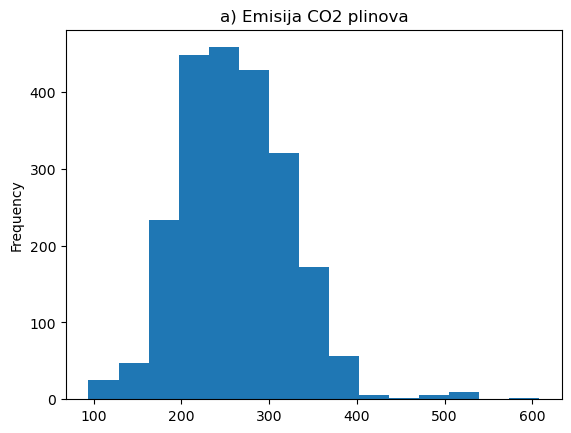

In [39]:
import matplotlib.pyplot as plt
data['CO2 Emissions (g/km)'].plot(kind='hist', bins=15)
plt.title('a) Emisija CO2 plinova')
plt.show()

Vrijednosti CO2 emisije kreću se od ~100 do ~600, pri čemu najveći broj automobila ima emisiju CO2 između 200 i 300 g/km. Emisije preko 400 g/km su rijetke s tek nekoliko desetaka primjeraka, ali i mali broj automobila ima emisije ispod 150 g/km.

b) Pomo´cu dijagrama raspršenja prikažite odnos izme ¯du gradske potrošnje goriva i emisije
C02 plinova. Komentirajte dobiveni prikaz. Kako biste bolje razumjeli odnose izme ¯du
veliˇcina, obojite toˇckice na dijagramu raspršenja s obzirom na tip goriva.

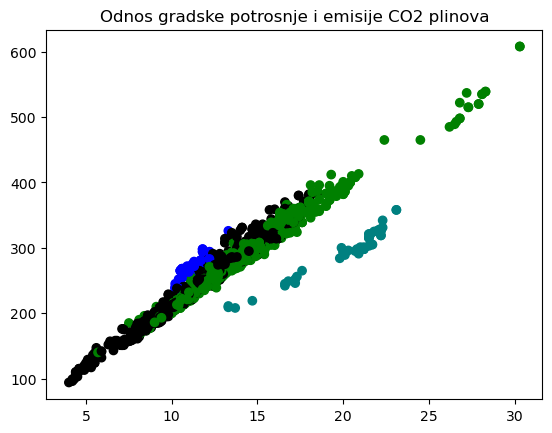

In [42]:
plt.scatter(x=data['Fuel Consumption City (L/100km)'], y=data['CO2 Emissions (g/km)'], c=data['Fuel Type'].map({'X': 'black', 'D': 'blue', 'Z': 'green', 'E': 'teal'}))
plt.title('Odnos gradske potrosnje i emisije CO2 plinova')
plt.show()

c) Pomo´cu kutijastog dijagrama prikažite razdiobu izvangradske potrošnje s obzirom na tip
goriva. Primje´cujete li grubu mjernu pogrešku u podacima?

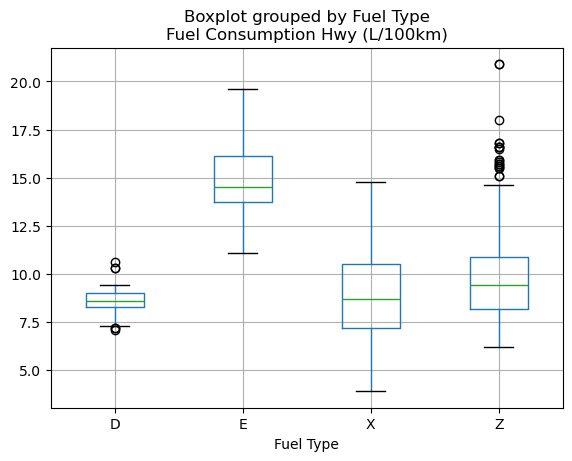

In [48]:
data.boxplot(column='Fuel Consumption Hwy (L/100km)', by='Fuel Type')
plt.show()

d) Pomo´cu stupˇcastog dijagrama prikažite broj vozila po tipu goriva. Koristite metodu
groupby.

/tmp/ipykernel_31368/253648604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Fuel Type').size().plot(kind='bar')


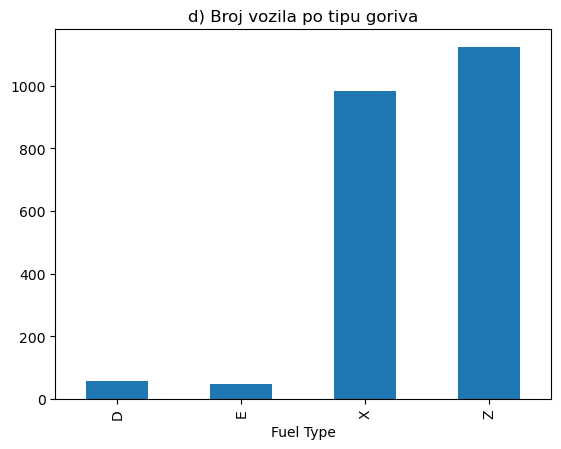

In [55]:
data.groupby('Fuel Type').size().plot(kind='bar')
plt.title('d) Broj vozila po tipu goriva')
plt.show()

e) Pomo´cu stupˇcastog grafa prikažite na istoj slici prosjeˇcnu C02 emisiju vozila s obzirom na
broj cilindara.

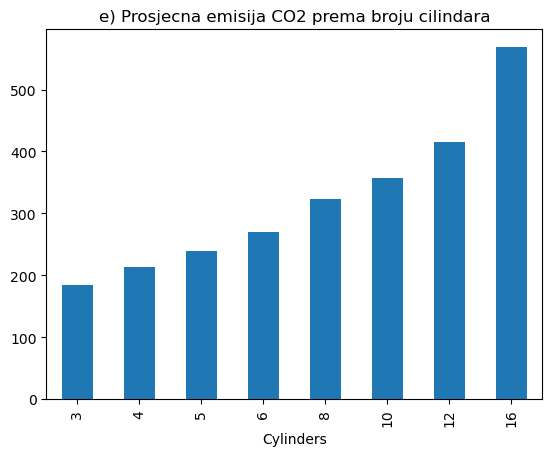

In [56]:
data.groupby('Cylinders')['CO2 Emissions (g/km)'].mean().plot(kind='bar')
plt.title('e) Prosjecna emisija CO2 prema broju cilindara')
plt.show()